# Putting it all together

We can put together what we have learned from the lectures and practical sessions to build a small accelerator simulation code. 

In [287]:
import numpy as np
from scipy.optimize import minimize

# calculate gamma from alpha and beta
def gam(alp, bet) :
    return (1+alp**2)/bet

# indentity matrix
def iden_matrix() :
    return np.array([[1, 0],[0, 1]])    

# drift matrix 
def drift_matrix(L) :
    return np.array([[1, L],[0,1 ]])

# thin quad matrix 
def quad_thin_matrix(f) :
    return np.array([[1, 0],[1/f,1 ]])

# thick quad matrix 
def quad_thick_matrix(L, k1) : 
    if k1 > 0 :
        return np.array([[np.cos(np.sqrt(k1)*L)               , 1/np.sqrt(k1)*np.sin(np.sqrt(k1)*L)], 
                         [-np.sqrt(k1)*np.sin(np.sqrt(k1)*L) , np.cos(np.sqrt(k1)*L)]]) 
    elif k1 < 0:
        k1 = abs(k1)
        return np.array([[np.cosh(np.sqrt(k1)*L)              , 1/np.sqrt(k1)*np.sinh(np.sqrt(k1)*L)], 
                         [np.sqrt(k1)*np.sinh(np.sqrt(k1)*L) , np.cosh(np.sqrt(k1)*L)]]) 
    else :
        return np.array([[1,0],[0,1]])

# matrix to propagate twiss 
def twiss_propagation(m) :
    return np.array([[m[0,0]**2     ,   -2*m[0,0]*m[0,1]  ,  m[0,1]**2],
                     [-m[0,0]*m[1,0], 1+ 2*m[0,1]*m[1,0], -m[0,1]*m[1,1]],
                     [m[1,0]**2     ,   -2*m[1,0]*m[1,1]  ,  m[1,1]**2]])

def optics(line, t0 = np.array([1,0,1])) :

    # Make line with S positions
    S = 0 # starting S is zero

    # loop over line adding up the lengths 
    for e in line :  
        S += e['L']
        e['S'] = S

    # Make transfer matrix for element
    rmat_prev = np.array([[1,0],
                          [0,1]])

    # loop over the elements 
    for e in line :
        if e['type'] == 'drift' :
            e['rmat'] = drift_matrix(e['L'])
        elif e['type'] == 'quad_thin' :
            e['rmat'] = quad_thin_matrix(e['f'])
        elif e['type'] == 'quad_thick' :
            e['rmat'] = quad_thick_matrix(e['L'], e['k1'])
        elif e['type'] == 'marker' :
            e['rmat'] = iden_matrix()

        # transfer matrix from start to end of current element
        e['rmat_s'] = e['rmat'] @ rmat_prev 
        
        # matrix to propagate twiss from start to end of current element
        e['tmat_s'] = twiss_propagation(e['rmat_s'])

        # apply twiss matrix to inital twiss vector 
        e['twiss'] = e['tmat_s'] @ t0 

        # keep a copy of the old rmat
        rmat_prev = e['rmat_s']
            
    return line

def plot(line) :
    import matplotlib.pyplot as plt
    
    S = []
    b = []
    a = []
    g = [] 
    for e in line: 
        S.append(e['S'])
        b.append(e['twiss'][0])
        a.append(e['twiss'][1])
        g.append(e['twiss'][2])
    
    plt.subplot(3,1,1)
    plt.plot(S,b,"o--")
    plt.xlabel("S")
    plt.ylabel("$\\beta$")
    
    plt.subplot(3,1,2)
    plt.plot(S,a,"o--")
    plt.xlabel("S")
    plt.ylabel("$\\alpha$")

    plt.subplot(3,1,3)
    plt.plot(S,g,"o--") 
    plt.xlabel("S")
    plt.ylabel("$\\gamma$")
    

## FODO example

This is the same as the XSuite example 


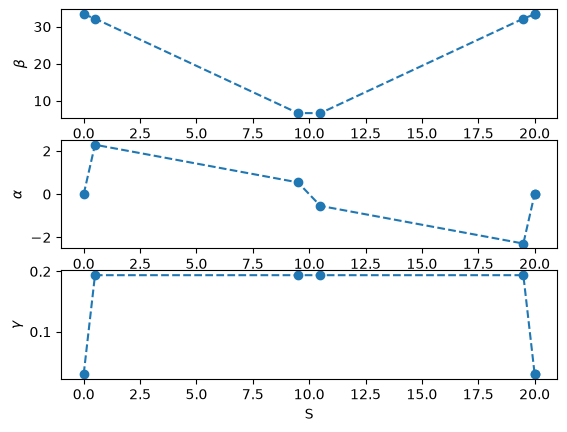

In [288]:
# this is the same as the XSuite example 

line = [{"name":"start", "type":"marker","L":0},
        {"name":"q1half", "type":"quad_thick","L":1/2, "k1":0.1414213562373095},
        {"name":"d1", "type":"drift","L":9},
        {"name":"q2", "type":"quad_thick","L":1, "k1":-0.1414213562373095},
        {"name":"d2", "type":"drift","L":9},
        {"name":"q1half", "type":"quad_thick","L":1/2, "k1":0.1414213562373095},
        {"name":"end","type":"marker","L":0}]

elems = optics(line, t0 = np.array([33.34856217,0.0,gam(0.0,33.34856217)]))

plot(elems)

## Exercises 

1. Focusing doublet. Calculate the focusing effect on beam from two quads
    1. Will need to expand the functions that create the $2\times2$ matricies to return $4\times 4$
    1. Calculate the Twiss propagation matrix in both $x$ and $y$. So by making a function that returns a $6\times 6$ matrix or calling the `twiss_propagation` function twice
    1. Upgrade the plotting so $x$ and $y$ can be plotted on the same axis
1. Track many particles through a sequence of elements to see the $(x, x^{\prime}$ phase space.
    1. You will need a function the generate particles in $(x, x^{\prime}$
    2. A function to apply the transfer matrices `rmat` in the code above      